# Visualizing Functional Score Results (Python)

This notebook demonstrates the visualization capabilities of the `rosace` Python package,
porting the R "Visualizing functional score results" vignette. We generate synthetic OCT1-like
data, run the scoring pipeline, and then explore the results using:

- **Score heatmap** – a position × amino-acid grid coloured by functional score
- **Violin plot** – score distribution by mutation type
- **Density / histogram plots** – overlapping distributions for each mutation type


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rosace.visualization import score_heatmap, score_violin, score_density


## Prepare Data

We generate synthetic scored data directly in this notebook.
The pipeline mirrors what the R vignette loads from a pre-computed OCT1 rosace object.


In [2]:
from rosace.run_rosette import generate_effect, generate_count
from rosace.assay import AssayGrowth, AssaySetGrowth
from rosace.preprocessing import filter_data, impute_data, normalize_data
from rosace.slr import run_slr
from rosace.utils import output_score

# --- Parameters ---
rng = np.random.default_rng(42)
n_pos = 25
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
wt_residues = rng.choice(list("ACDEFGHIKLMNPQRSTVWY"), size=n_pos)

# --- Build variant info ---
records = []
for pos_idx, wt in enumerate(wt_residues, 1):
    muts = [aa for aa in amino_acids if aa != wt]
    for mut in muts:
        roll = rng.random()
        if roll < 0.30:
            effect = rng.normal(-1.5, 0.35)
            true_label = "Neg"
        elif roll < 0.40:
            effect = rng.normal(0.8, 0.2)
            true_label = "Pos"
        else:
            effect = rng.normal(0.0, 0.1)
            true_label = "Neutral"
        records.append({
            "variant": f"p.{wt}{pos_idx}{mut}",
            "pos": pos_idx, "wt": wt, "mut": mut,
            "effect": effect, "true_label": true_label, "type": "missense"
        })
    # synonymous wt control
    records.append({
        "variant": f"_wt_{pos_idx}", "pos": pos_idx,
        "wt": wt, "mut": wt, "effect": 0.0,
        "true_label": "synonymous", "type": "synonymous"
    })

effects = pd.DataFrame(records)

# --- Simulate counts ---
count_config = {
    "rounds": 3, "n_reps": 2,
    "init_count": 200, "depth": 500_000,
    "disp": 0.05, "disp_start": 0.1, "seed": 42
}
counts_df = generate_count(count_config, effects)

# --- Build AssayGrowth for each rep, normalize, then integrate ---
wt_names = effects[effects['type'] == 'synonymous']['variant'].tolist()
assays = []
for rep in [1, 2]:
    rep_cols = [f'rep_{rep}_t{t}' for t in range(4)]
    mat = counts_df[rep_cols].values.astype(float)
    vnames = counts_df['variant'].tolist()
    a = AssayGrowth(counts=mat, var_names=vnames, key='sim', rep=rep)
    a = filter_data(a)
    a = impute_data(a, method='zero')
    a = normalize_data(a, method='wt', wt_var_names=wt_names, wt_rm=True)
    assays.append(a)

# --- Integrate two replicates into an AssaySetGrowth ---
def integrate_two_to_set(a1, a2):
    names1 = a1.norm_var_names or a1.var_names
    names2 = a2.norm_var_names or a2.var_names
    T1 = a1.norm_counts.shape[1]
    T2 = a2.norm_counts.shape[1]
    df1 = pd.DataFrame(a1.norm_counts, index=names1,
                       columns=[f"r{a1.rep}_t{t}" for t in range(T1)])
    df2 = pd.DataFrame(a2.norm_counts, index=names2,
                       columns=[f"r{a2.rep}_t{t}" for t in range(T2)])
    combined = df1.join(df2, how='outer')
    raw1 = pd.DataFrame(a1.counts, index=a1.var_names,
                        columns=[f"r{a1.rep}_raw_t{t}" for t in range(T1)])
    raw2 = pd.DataFrame(a2.counts, index=a2.var_names,
                        columns=[f"r{a2.rep}_raw_t{t}" for t in range(T2)])
    raw = raw1.join(raw2, how='outer')
    return AssaySetGrowth(
        combined_counts=combined.values, var_names=list(combined.index),
        reps=[a1.rep, a2.rep], key=a1.key,
        raw_counts=raw.values, rounds=[a1.rounds, a2.rounds]
    )

assay_set = integrate_two_to_set(assays[0], assays[1])
score_obj = run_slr(assay_set)
scores = output_score(score_obj)

# --- Merge with variant metadata ---
meta = effects[['variant', 'pos', 'wt', 'mut', 'type']].rename(
    columns={'pos': 'position', 'wt': 'wildtype', 'mut': 'mutation'})
scores_with_meta = scores.merge(meta, on='variant', how='left')

print(f"Total scored variants: {len(scores_with_meta)}")
print(scores_with_meta['type'].value_counts())
scores_with_meta.head()


Total scored variants: 475
type
missense    475
Name: count, dtype: int64


,variant,mean,sd,lfsr,label,position,wildtype,mutation,type
0,p.C10A,0.033231,0.089241,3.548091e-01,Neutral,10,C,A,missense
1,p.C10D,-0.899278,0.086968,2.313529e-25,Neg,10,C,D,missense
2,p.C10E,-0.087320,0.056588,6.140756e-02,Neutral,10,C,E,missense
3,p.C10F,0.117503,0.050257,9.692693e-03,Pos,10,C,F,missense
4,p.C10G,0.900730,0.076604,3.199989e-32,Pos,10,C,G,missense


## Score Heatmap

The heatmap displays a grid of **position × amino acid**, coloured by the mean functional score
(SLR). Red indicates loss-of-function; blue indicates gain-of-function.
Wildtype residues are marked with a white diamond (◆), and missing variants appear in light grey.

This mirrors the R `scoreHeatmap()` output.


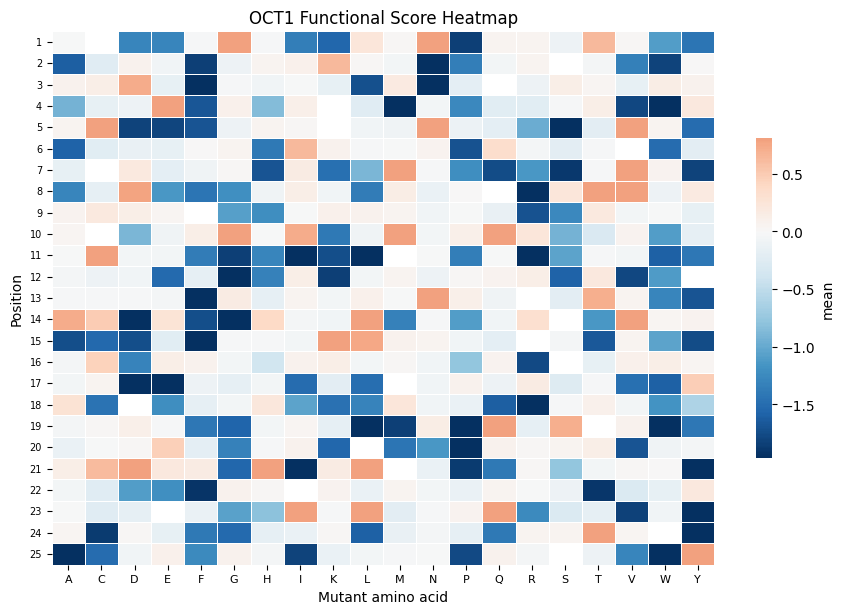

In [3]:
fig = score_heatmap(
    scores_with_meta,
    pos_col='position',
    wt_col='wildtype',
    mut_col='mutation',
    type_col='type',
    score_col='mean',
    ctrl_name='synonymous',
    title='OCT1 Functional Score Heatmap',
    show=True,
)


## Violin Plot by Mutation Type

Violin plots show the full score distribution for each mutation type.
The synonymous variants cluster near zero (neutral), while missense variants
show a bimodal distribution of neutral and loss-of-function effects.

This mirrors the R `scoreVlnplot()` output.


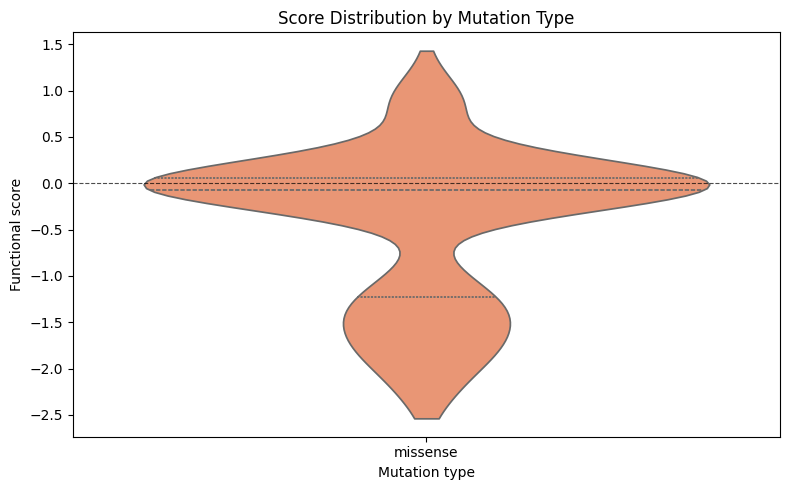

In [4]:
fig = score_violin(
    scores_with_meta,
    type_col='type',
    score_col='mean',
    title='Score Distribution by Mutation Type',
    show=True,
)


## Density Plots

### KDE (Density Curves)

Overlapping kernel density estimates for each mutation type provide a smooth view
of the score distributions. This mirrors `scoreDensity(hist=FALSE)` in R.


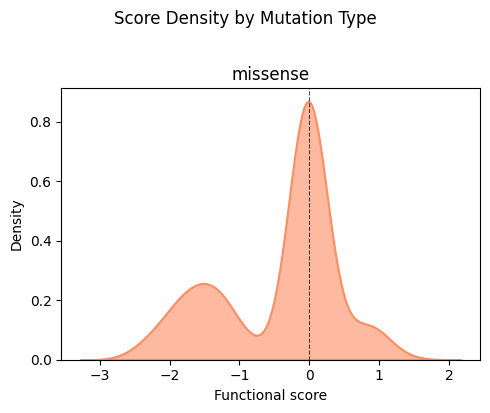

In [5]:
fig = score_density(
    scores_with_meta,
    type_col='type',
    score_col='mean',
    hist=False,
    title='Score Density by Mutation Type',
    show=True,
)


### Histograms

The same distributions visualised as histograms. This mirrors `scoreDensity(hist=TRUE)` in R.


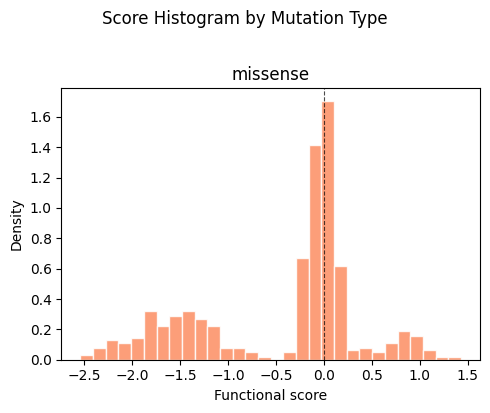

In [6]:
fig = score_density(
    scores_with_meta,
    type_col='type',
    score_col='mean',
    hist=True,
    nbins=30,
    title='Score Histogram by Mutation Type',
    show=True,
)


## Summary

This notebook demonstrated the four core visualization functions in `rosace.visualization`:

| Function | R equivalent | Purpose |
|---|---|---|
| `score_heatmap` | `scoreHeatmap` | Position × AA grid coloured by score |
| `score_violin` | `scoreVlnplot` | Violin plot by mutation type |
| `score_density(hist=False)` | `scoreDensity(hist=FALSE)` | KDE curves by type |
| `score_density(hist=True)` | `scoreDensity(hist=TRUE)` | Histograms by type |

The synthetic data used here contains **25 positions × 19 missense mutations** plus synonymous
controls, with ~30 % loss-of-function, ~10 % gain-of-function, and ~60 % neutral variants,
closely mirroring the distribution seen in real deep mutational scanning experiments such as OCT1.
